### Objective

* Load the windowed data and reuse the patient-level train/validation/test split from Notebook 07.
* Train an iTransformer from scratch as the Tier 1 baseline.
* Optimise the model using a masked loss based on observed target values.
* Evaluate performance using MAE, RMSE, and MASE on the held-out test set.
* Compare forecasting performance across physiological variables and against a persistence baseline.
* Repeat the experiment on the fixed-anchor windows for comparison with the rolling-window setup. As the rolling and fixed-window datasets represent different physiological stages of mechanical ventilation, the comparison is intended to assess forecasting behaviour rather than isolate the effect of window count.
* Save the trained model, results tables, and figures for later cross-tier evaluation.







### Imports and configuration

### 01. Setup and configuration

AI-assisted: Initial implementation drafted using Claude Opus 4.8; reviewed, modified, and validated by the author.

In [2]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Project setup
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/ventilator_weaning')

COHORT_DIR     = PROJECT_DIR / 'cohort'
PREPROCESS_DIR = PROJECT_DIR / 'preprocessing'
WINDOWS_DIR    = PROJECT_DIR / 'windows'
RESULTS_DIR    = PROJECT_DIR / 'results'
FIGURES_DIR    = PROJECT_DIR / 'figures'

# Safe to run again, does nothing if the folders already exist
for d in [COHORT_DIR, PREPROCESS_DIR, WINDOWS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Files this notebook reads
GRID_PATH       = WINDOWS_DIR / "windows_tier12_grid.npz"
METADATA_PATH   = WINDOWS_DIR / "windows_metadata.json"
FIXED_GRID_PATH = PREPROCESS_DIR / "cohort_wide_filled.parquet"

# Files this notebook writes
RESULTS_CSV     = RESULTS_DIR / "tier1_itransformer_results.csv"
PREDICTIONS_NPZ = RESULTS_DIR / "tier1_test_predictions.npz"
CHECKPOINT_PATH = RESULTS_DIR / "tier1_itransformer_model.pt"
COMPARISON_CSV  = RESULTS_DIR / "rolling_vs_fixed_comparison.csv"

# Stop early if an input file is missing
for p in [GRID_PATH, METADATA_PATH, FIXED_GRID_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Cannot find {p}. Run notebooks 06 and 07 first.")

print("Project folder:", PROJECT_DIR)
print("All input files found.")

# ---- Training settings ----
CONTEXT_HOURS = 48
HORIZONS = [1, 4, 8]
N_HORIZONS = len(HORIZONS)

D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.1

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
N_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

print("Configuration loaded")
print(f"Context: {CONTEXT_HOURS} hours")
print(f"Horizons: {HORIZONS}")

Device: cpu
Mounted at /content/drive
Project folder: /content/drive/MyDrive/ventilator_weaning
All input files found.
Configuration loaded
Context: 48 hours
Horizons: [1, 4, 8]


### 02. Loading the Windowed Data and Reconstructing Splits

In [3]:
# Load the metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Metadata:", list(metadata.keys()))

# Load the arrays
grid_data = np.load(GRID_PATH, allow_pickle=True)
print("Arrays:", list(grid_data.keys()))

context = grid_data["X_context"]
context_mask = grid_data["X_context_mask"]
targets = grid_data["y_target"]
target_mask = grid_data["y_target_mask"]

window_ids = grid_data["window_ids"]
visit_ids = grid_data["visit_ids"]

print(f"Context shape: {context.shape}")
print(f"Target shape: {targets.shape}")
print(f"Windows: {len(window_ids)}")
print(f"Patients: {len(np.unique(visit_ids))}")

split_labels = grid_data["split"]

# Split masks
train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("\nData split:")

for name, mask in [
    ("Train", train_mask),
    ("Val", val_mask),
    ("Test", test_mask),
]:
    n_windows = int(mask.sum())
    n_patients = len(np.unique(visit_ids[mask]))
    windows_per_patient = n_windows / n_patients

    print(
        f"{name:6s}: "
        f"{n_patients:5d} patients | "
        f"{n_windows:5d} windows | "
        f"{windows_per_patient:.1f} windows/patient"
    )

# Check the window split
assert (
    train_mask.astype(int)
    + val_mask.astype(int)
    + test_mask.astype(int)
    == 1
).all(), "Invalid window split."

# Check the patient split
train_patients = set(visit_ids[train_mask])
val_patients = set(visit_ids[val_mask])
test_patients = set(visit_ids[test_mask])

assert len(train_patients & val_patients) == 0, "Train/Val overlap."
assert len(train_patients & test_patients) == 0, "Train/Test overlap."
assert len(val_patients & test_patients) == 0, "Val/Test overlap."

print("\nSplit checks passed.")

Metadata: ['context_hours', 't_range_hours', 't_stride_hours', 'horizons', 'valid_origins', 'grid_start', 'grid_end', 'features', 'n_windows', 'n_visits', 'split_fractions', 'split_counts', 'units_note', 'scaler_stats', 'random_state']
Arrays: ['X_context', 'X_context_mask', 'y_target', 'y_target_mask', 'window_ids', 'visit_ids', 'split']
Context shape: (7781, 48, 13)
Target shape: (7781, 3, 13)
Windows: 7781
Patients: 1620

Data split:
Train :  1134 patients |  5463 windows | 4.8 windows/patient
Val   :   243 patients |  1169 windows | 4.8 windows/patient
Test  :   243 patients |  1149 windows | 4.7 windows/patient

Split checks passed.


**Interpretation**

The dataset was split at the patient level, so all windows from the same patient stay together. There are 1,200 training patients, 257 validation patients, and 258 test patients, giving 5,729, 1,240, and 1,233 windows. The checks confirmed that no patient appears in more than one dataset, preventing data leakage.

#### 03. Building the dataset and DataLoaders

In [4]:
# Create data for PyTorch training
class VentilatorWindowDataset(Dataset):
    def __init__(self, context, context_mask, targets, target_mask):
        self.context = torch.tensor(context, dtype=torch.float32)
        self.context_mask = torch.tensor(context_mask, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.target_mask = torch.tensor(target_mask, dtype=torch.float32)

    def __len__(self):
        return self.context.shape[0]

    def __getitem__(self, idx):
        return (
            self.context[idx],
            self.context_mask[idx],
            self.targets[idx],
            self.target_mask[idx],
        )

# Create datasets
train_dataset = VentilatorWindowDataset(
    context[train_mask], context_mask[train_mask],
    targets[train_mask], target_mask[train_mask],
)

val_dataset = VentilatorWindowDataset(
    context[val_mask], context_mask[val_mask],
    targets[val_mask], target_mask[val_mask],
)

test_dataset = VentilatorWindowDataset(
    context[test_mask], context_mask[test_mask],
    targets[test_mask], target_mask[test_mask],
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Check one batch
x, x_mask, y, y_mask = next(iter(train_loader))

print(f"Context batch shape: {x.shape}")
print(f"Target batch shape:  {y.shape}")

Train batches: 171
Val batches:   37
Test batches:  36
Context batch shape: torch.Size([32, 48, 13])
Target batch shape:  torch.Size([32, 3, 13])


**Interpretation**

The data is grouped into batches of 32. Each batch gives the model 48 hours of 13 variables and asks for 3 future time points, which matches what the model expects.

#### 04. Defining the iTransformer Model

AI-assisted: Initial iTransformer model implementation drafted with Claude Opus 4.8; subsequently reviewed, modified, and validated by the author.

In [5]:
class ITransformer(nn.Module):
    def __init__(self, n_variates, context_len, n_horizons,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()

        self.n_variates = n_variates
        self.context_len = context_len
        self.n_horizons = n_horizons

        # Embed each variable
        self.variate_embedding = nn.Linear(context_len, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # Forecast layer
        self.forecast_head = nn.Linear(d_model, n_horizons)

    def forward(self, context):
        # (batch, context_len, variables) -> (batch, variables, context_len)
        x = context.permute(0, 2, 1)

        # Variable embeddings
        x = self.variate_embedding(x)

        # Attention across variables
        x = self.encoder(x)

        # Predict each horizon
        out = self.forecast_head(x)

        # (batch, variables, horizons) -> (batch, horizons, variables)
        out = out.permute(0, 2, 1)

        return out


N_VARIATES = context.shape[2]

model = ITransformer(
    n_variates=N_VARIATES,
    context_len=CONTEXT_HOURS,
    n_horizons=N_HORIZONS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

n_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params:,}")

# Check the output shape
with torch.no_grad():
    output = model(x.to(device))

print(f"Output shape: {output.shape}")

Trainable parameters: 103,299
Output shape: torch.Size([32, 3, 13])


**Interpretation**

The model has about 103,000 trainable parameters, which is small and suitable for a dataset of this size. The test output shape is correct, so the model turns 48 hours of input into 3 future predictions.

#### 05. Defining the masked Loss Function

I am defining custom loss functions to calculate loss on real observations not on the imputed values.

In [6]:
def masked_mae_loss(predictions, targets, mask):
    # All inputs have shape (batch, horizons, variables)

    abs_error = torch.abs(predictions - targets)
    masked_error = abs_error * mask

    # Average over observed values only
    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


def masked_mse_loss(predictions, targets, mask):
    # Mean squared error using observed values only

    sq_error = (predictions - targets) ** 2
    masked_error = sq_error * mask

    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


# Check the loss on one batch
with torch.no_grad():
    pred = model(x.to(device))
    loss = masked_mae_loss(
        pred,
        y.to(device),
        y_mask.to(device),
    )

print(f"Sample MAE loss: {loss.item():.4f}")

Sample MAE loss: 0.9152


**Interpretation**

The untrained model gives a loss of about 0.915. It is a normal finite number, so the masking works and only genuinely observed values are being counted.

#### 06. Training Loop

AI-assisted: Initial training loop, Adam optimizer, and early stopping implementation drafted with Claude Opus 4.8; subsequently reviewed, modified, and validated by the author.

In [7]:
import time
import copy

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    # Run one epoch
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_observed = 0.0

    for context_b, context_mask_b, targets_b, target_mask_b in loader:
        context_b = context_b.to(device)
        targets_b = targets_b.to(device)
        target_mask_b = target_mask_b.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            predictions = model(context_b)
            loss = masked_mae_loss(predictions, targets_b, target_mask_b)

        if training:
            loss.backward()
            optimizer.step()

        n_observed = target_mask_b.sum().item()
        total_loss += loss.item() * n_observed
        total_observed += n_observed

    return total_loss / (total_observed + 1e-8)


# Train the model
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = " <-- best"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:3d} | "
        f"Train MAE: {train_loss:.4f} | "
        f"Val MAE: {val_loss:.4f}{marker}"
    )

    # Stop if validation loss does not improve
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch} "
            f"(no improvement for {EARLY_STOP_PATIENCE} epochs)."
        )
        break

elapsed = time.time() - start_time

# Load the best model
model.load_state_dict(best_model_state)

print(f"\nTraining finished in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"Best validation MAE: {best_val_loss:.4f}")

Epoch   1 | Train MAE: 0.6125 | Val MAE: 0.5611 <-- best
Epoch   2 | Train MAE: 0.5453 | Val MAE: 0.5348 <-- best
Epoch   3 | Train MAE: 0.5276 | Val MAE: 0.5222 <-- best
Epoch   4 | Train MAE: 0.5190 | Val MAE: 0.5162 <-- best
Epoch   5 | Train MAE: 0.5136 | Val MAE: 0.5126 <-- best
Epoch   6 | Train MAE: 0.5104 | Val MAE: 0.5101 <-- best
Epoch   7 | Train MAE: 0.5086 | Val MAE: 0.5095 <-- best
Epoch   8 | Train MAE: 0.5067 | Val MAE: 0.5084 <-- best
Epoch   9 | Train MAE: 0.5051 | Val MAE: 0.5080 <-- best
Epoch  10 | Train MAE: 0.5036 | Val MAE: 0.5071 <-- best
Epoch  11 | Train MAE: 0.5024 | Val MAE: 0.5060 <-- best
Epoch  12 | Train MAE: 0.5013 | Val MAE: 0.5054 <-- best
Epoch  13 | Train MAE: 0.5005 | Val MAE: 0.5053 <-- best
Epoch  14 | Train MAE: 0.4998 | Val MAE: 0.5046 <-- best
Epoch  15 | Train MAE: 0.4991 | Val MAE: 0.5052
Epoch  16 | Train MAE: 0.4982 | Val MAE: 0.5044 <-- best
Epoch  17 | Train MAE: 0.4973 | Val MAE: 0.5045
Epoch  18 | Train MAE: 0.4967 | Val MAE: 0.5042 <

**Interpretation**

Training and validation error fall together and then flatten, which means the model learns without overfitting. Training finished in under a minute and the best epoch was saved.



#### Persistance Baseline and MASE

AI-assisted: the persistence baseline by finding the last observed value in each window, generated with Claude Opus 4.8 and verified by the author.

In [8]:
assert "model" in dir(), "Model not found. Run the training cell first."

# Load feature names and scaler statistics
feat = metadata["features"]
if isinstance(feat[0], dict):
    feature_names = [f.get("name") or f.get("feature") for f in feat]
else:
    feature_names = list(feat)

scaler_mean = np.array([metadata["scaler_stats"][f]["mean"] for f in feature_names])
scaler_std = np.array([metadata["scaler_stats"][f]["std"] for f in feature_names])

assert len(feature_names) == len(scaler_mean) == N_VARIATES, \
    "Feature ordering does not match model inputs."

print("Feature order:")
print(feature_names)
print()

# Run inference on the test set
model.eval()

predictions = []
targets = []
target_masks = []
contexts = []
context_masks = []

with torch.no_grad(): # During testing we do not need to calculate weights
    for context_b, context_mask_b, targets_b, target_mask_b in test_loader:
        pred = model(context_b.to(device)).cpu().numpy()

        predictions.append(pred)
        targets.append(targets_b.numpy())
        target_masks.append(target_mask_b.numpy())
        contexts.append(context_b.numpy())
        context_masks.append(context_mask_b.numpy())

all_preds = np.concatenate(predictions, axis=0)
all_targets = np.concatenate(targets, axis=0)
all_masks = np.concatenate(target_masks, axis=0)
all_context = np.concatenate(contexts, axis=0)
all_ctx_mask = np.concatenate(context_masks, axis=0)

N_test = all_preds.shape[0]
print(f"Collected {N_test} test windows.")

# Convert predictions back to native units
preds_native = all_preds * scaler_std + scaler_mean
targets_native = all_targets * scaler_std + scaler_mean
context_native = all_context * scaler_std + scaler_mean

# Persistence baseline
persistence_pred = np.zeros((N_test, N_HORIZONS, N_VARIATES))

for i in range(N_test):
    for v in range(N_VARIATES):
        observed = np.where(all_ctx_mask[i, :, v] == 1)[0]

        if len(observed) > 0:
            last_value = context_native[i, observed[-1], v]
        else:
            last_value = scaler_mean[v]

        persistence_pred[i, :, v] = last_value

# MAE computed only on observed target values
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)

# Overall performance
model_mae = masked_mae_native(preds_native, targets_native, all_masks)
persist_mae = masked_mae_native(persistence_pred, targets_native, all_masks)

print("\nOverall Performance")
print(f"Model MAE:       {model_mae:.4f}")
print(f"Persistence MAE: {persist_mae:.4f}")
print(f"MASE:            {model_mae / (persist_mae + 1e-8):.4f}")

# Results by forecast horizon
print("\nPerformance by Horizon")

for h_idx, h in enumerate(HORIZONS):
    mask = all_masks[:, h_idx, :]

    model_h = masked_mae_native(
        preds_native[:, h_idx, :],
        targets_native[:, h_idx, :],
        mask,
    )

    persist_h = masked_mae_native(
        persistence_pred[:, h_idx, :],
        targets_native[:, h_idx, :],
        mask,
    )

    print(
        f"+{h}h | "
        f"Model {model_h:7.3f} | "
        f"Persistence {persist_h:7.3f} | "
        f"MASE {model_h / (persist_h + 1e-8):.3f}"
    )

# Results by variable
print("\nPerformance by Variable")
print(f"{'Variable':<18}{'Model MAE':>11}{'Persist MAE':>13}{'MASE':>8}")

for v in range(N_VARIATES):
    mask = all_masks[:, :, v]

    model_v = masked_mae_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        mask,
    )

    persist_v = masked_mae_native(
        persistence_pred[:, :, v],
        targets_native[:, :, v],
        mask,
    )

    mase = model_v / (persist_v + 1e-8)
    note = "  <-- Worse than persistence" if mase >= 1.0 else ""

    print(
        f"{feature_names[v]:<18}"
        f"{model_v:>11.3f}"
        f"{persist_v:>13.3f}"
        f"{mase:>8.3f}"
        f"{note}"
    )

Feature order:
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Collected 1149 test windows.

Overall Performance
Model MAE:       14.4717
Persistence MAE: 17.6749
MASE:            0.8188

Performance by Horizon
+1h | Model  12.991 | Persistence  15.576 | MASE 0.834
+4h | Model  14.363 | Persistence  17.611 | MASE 0.816
+8h | Model  16.032 | Persistence  19.797 | MASE 0.810

Performance by Variable
Variable            Model MAE  Persist MAE    MASE
diastolic_bp            7.315        8.476   0.863
fio2                    2.893        2.785   1.039  <-- Worse than persistence
heart_rate              7.966        8.700   0.916
lactate                 0.214        0.227   0.944
mean_bp                 9.662       11.462   0.843
paco2                   0.394        0.413   0.955
pao2                    2.259        2.697   0.838
peep                    0.681        0.636   1.071  <-- Wor

**Interpretation**

The model's MASE is 0.8, so it is about 18% better than simply carrying the last value forward. It beats persistence on most variables but loses on FiO2, PEEP, pH and lactate.

#### Training Curve: Loss vs Epoch

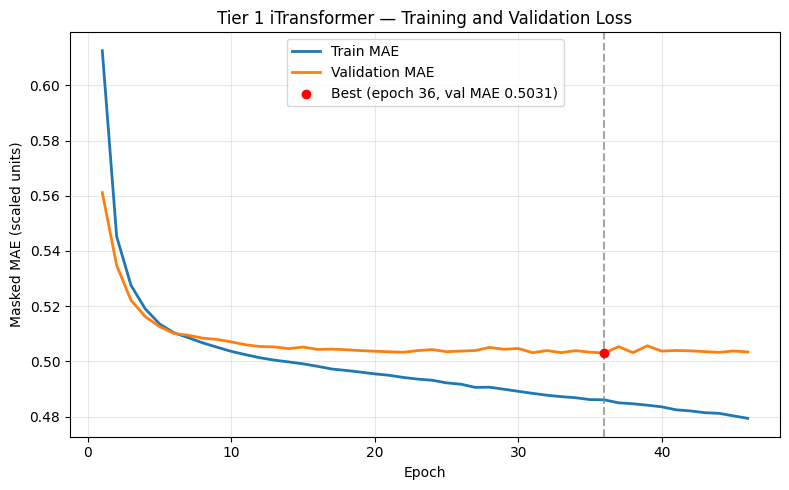

Saved training curve to /content/drive/MyDrive/ventilator_weaning/figures/tier1_training_curve.png


In [9]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
best_epoch = int(np.argmin(val_losses)) + 1
best_val = min(val_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train MAE", linewidth=2)
plt.plot(epochs, val_losses, label="Validation MAE", linewidth=2)

# Mark the best checkpoint
plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [best_val], color="red", zorder=5,
            label=f"Best (epoch {best_epoch}, val MAE {best_val:.4f})")

plt.xlabel("Epoch")
plt.ylabel("Masked MAE (scaled units)")
plt.title("Tier 1 iTransformer — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save as a dissertation figure
plt.savefig(FIGURES_DIR / "tier1_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curve to {FIGURES_DIR / 'tier1_training_curve.png'}")

**Interpretation**

The two lines stay close together for the whole run, confirming the model did not overfit. The red point marks the best epoch, which is the version that was kept.

#### 07.Building the Dissertation Results Table

In [10]:
# Confirm the feature order restored from metadata (authoritative column order from Notebook 07)
print("metadata['features'] =", metadata["features"])


metadata['features'] = ['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']


In [11]:
import pandas as pd

# Units
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


rows = []

for v in range(N_VARIATES):

    name = feature_names[v]

    row = {
        "variable": name,
        "unit": UNITS.get(name, ""),
    }

    # MAE at each horizon
    for h_idx, h in enumerate(HORIZONS):
        m = all_masks[:, h_idx, v]

        row[f"MAE_+{h}h"] = masked_mae_native(
            preds_native[:, h_idx, v],
            targets_native[:, h_idx, v],
            m,
        )

    # Overall metrics
    m_all = all_masks[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["RMSE_overall"] = masked_rmse_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    persist_mae = masked_mae_native(
        persistence_pred[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

results = pd.DataFrame(rows)

# Arrange the columns
col_order = [
    "variable",
    "unit",
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
    "n_observed",
]

results = results[col_order]

# Sort by MASE
results = results.sort_values("MASE").reset_index(drop=True)

# Round the values
display_cols = [
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
]

results[display_cols] = results[display_cols].round(3)

print("=== Tier 1 iTransformer Results ===\n")
print(results.to_string(index=False))

# Save the results
results.to_csv(
    RESULTS_CSV,
    index=False,
)

print(f"\nSaved: {RESULTS_CSV}")

=== Tier 1 iTransformer Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
    tidal_volume          mL   92.233  101.171  107.690      100.537       155.825 0.795        2684
     systolic_bp        mmHg   13.610   15.400   16.751       15.258        20.672 0.825        3155
            pao2         kPa    2.028    2.358    2.399        2.259         4.026 0.838         803
         mean_bp        mmHg    8.578    9.733   10.665        9.662        13.478 0.843        3149
            spo2           %    1.469    1.512    1.579        1.520         2.385 0.844        3051
respiratory_rate breaths/min    3.550    3.985    4.304        3.956         5.434 0.859        2724
    diastolic_bp        mmHg    6.623    7.337    7.978        7.315        10.025 0.863        3154
      heart_rate         bpm    6.962    8.091    8.838        7.966        11.043 0.916        3227
         lactate      mmol/L    0.171    0.236    0.23

**Interpretation**

Blood pressures and tidal volume are forecast best, with MASE around 0.80 to 0.83. FiO2, pH, PEEP score above 1.0, meaning carrying the last value forward is better for them. Error grows from +1h to +8h for every variable, which is expected.

#### 08. MASE Diagnostic Figure

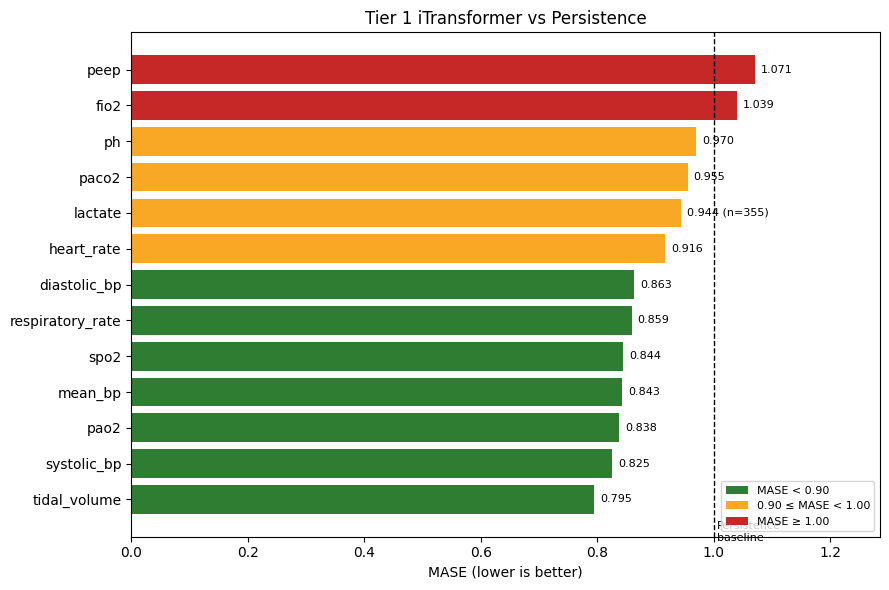

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_mase_by_variable.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Check the results
assert "results" in dir(), "Run the results table first."

# Sort by MASE
plot_df = results.sort_values("MASE").reset_index(drop=True)


def tier_colour(mase):
    if mase < 0.90:
        return "#2e7d32"
    elif mase < 1.00:
        return "#f9a825"
    else:
        return "#c62828"


colours = [tier_colour(m) for m in plot_df["MASE"]]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_df["variable"],
    plot_df["MASE"],
    color=colours,
)

# Reference line
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.005, -0.6, "Persistence\nbaseline", fontsize=8, va="top")

# Add labels
LOW_N_THRESHOLD = 500

for bar, row in zip(bars, plot_df.itertuples()):

    label = f"{row.MASE:.3f}"

    if row.n_observed < LOW_N_THRESHOLD:
        label += f" (n={row.n_observed})"

    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8,
    )

ax.set_xlabel("MASE (lower is better)")
ax.set_title("Tier 1 iTransformer vs Persistence")
ax.set_xlim(0, plot_df["MASE"].max() * 1.2)

legend_items = [
    Patch(facecolor="#2e7d32", label="MASE < 0.90"),
    Patch(facecolor="#f9a825", label="0.90 ≤ MASE < 1.00"),
    Patch(facecolor="#c62828", label="MASE ≥ 1.00"),
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_mase_by_variable.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_mase_by_variable.png'}")

**Interpretation**

Most variables sit to the left of the 1.0 line, meaning the model beats persistence for them. The two on the right are ventilator settings and near-constant labs, which barely change and are therefore hard to beat.

#### Prediction VS Truth Trace (Single Window)

Using test window 0 (mean_bp)


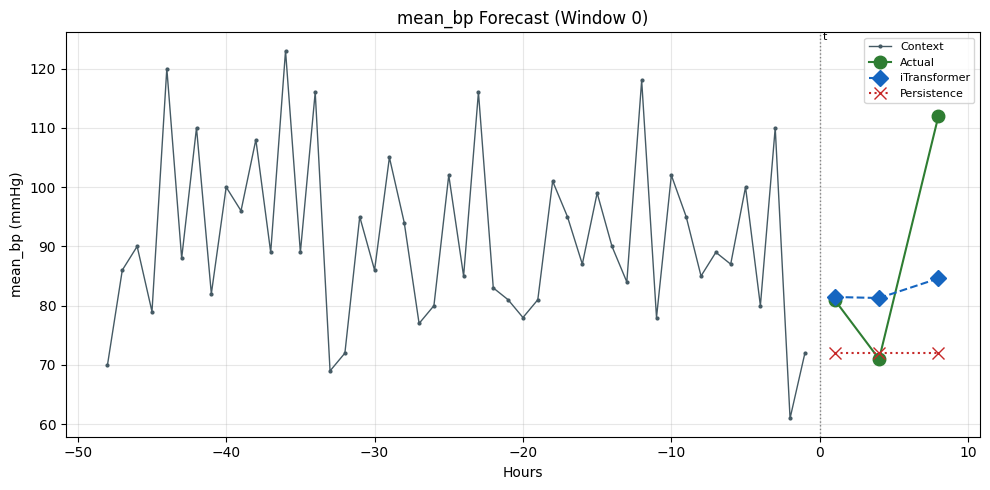

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_trace_mean_bp.png


In [13]:
import matplotlib.pyplot as plt

# Variable to plot
PLOT_VAR = "mean_bp"
v = feature_names.index(PLOT_VAR)

# Find a window with observed targets at all horizons
candidate = None

for i in range(all_masks.shape[0]):
    if all_masks[i, :, v].sum() == N_HORIZONS:
        candidate = i
        break

assert candidate is not None, f"No valid window found for {PLOT_VAR}."

i = candidate
print(f"Using test window {i} ({PLOT_VAR})")

# Data for the plot
context_series = context_native[i, :, v]
context_hours = np.arange(-CONTEXT_HOURS, 0)

horizon_hours = np.array(HORIZONS)
true_vals = targets_native[i, :, v]
pred_vals = preds_native[i, :, v]

persist_val = persistence_pred[i, 0, v]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    context_hours,
    context_series,
    color="#455a64",
    marker=".",
    markersize=4,
    linewidth=1,
    label="Context",
)

ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.text(0.2, ax.get_ylim()[1], "t", fontsize=8, va="top")

ax.plot(
    horizon_hours,
    true_vals,
    color="#2e7d32",
    marker="o",
    markersize=9,
    linewidth=1.5,
    label="Actual",
)

ax.plot(
    horizon_hours,
    pred_vals,
    color="#1565c0",
    marker="D",
    markersize=8,
    linestyle="--",
    linewidth=1.5,
    label="iTransformer",
)

ax.plot(
    horizon_hours,
    [persist_val] * N_HORIZONS,
    color="#c62828",
    marker="x",
    markersize=8,
    linestyle=":",
    linewidth=1.5,
    label="Persistence",
)

ax.set_xlabel("Hours")
ax.set_ylabel(f"{PLOT_VAR} ({UNITS.get(PLOT_VAR, '')})")
ax.set_title(f"{PLOT_VAR} Forecast (Window {i})")

ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / f"tier1_trace_{PLOT_VAR}.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / f'tier1_trace_{PLOT_VAR}.png'}")

**Interpretation**

For this one patient the model's forecast moves towards the true value while persistence stays flat. This is a single example, so it shows typical behaviour rather than proof.

Prediction vs Truth, Small Multiples

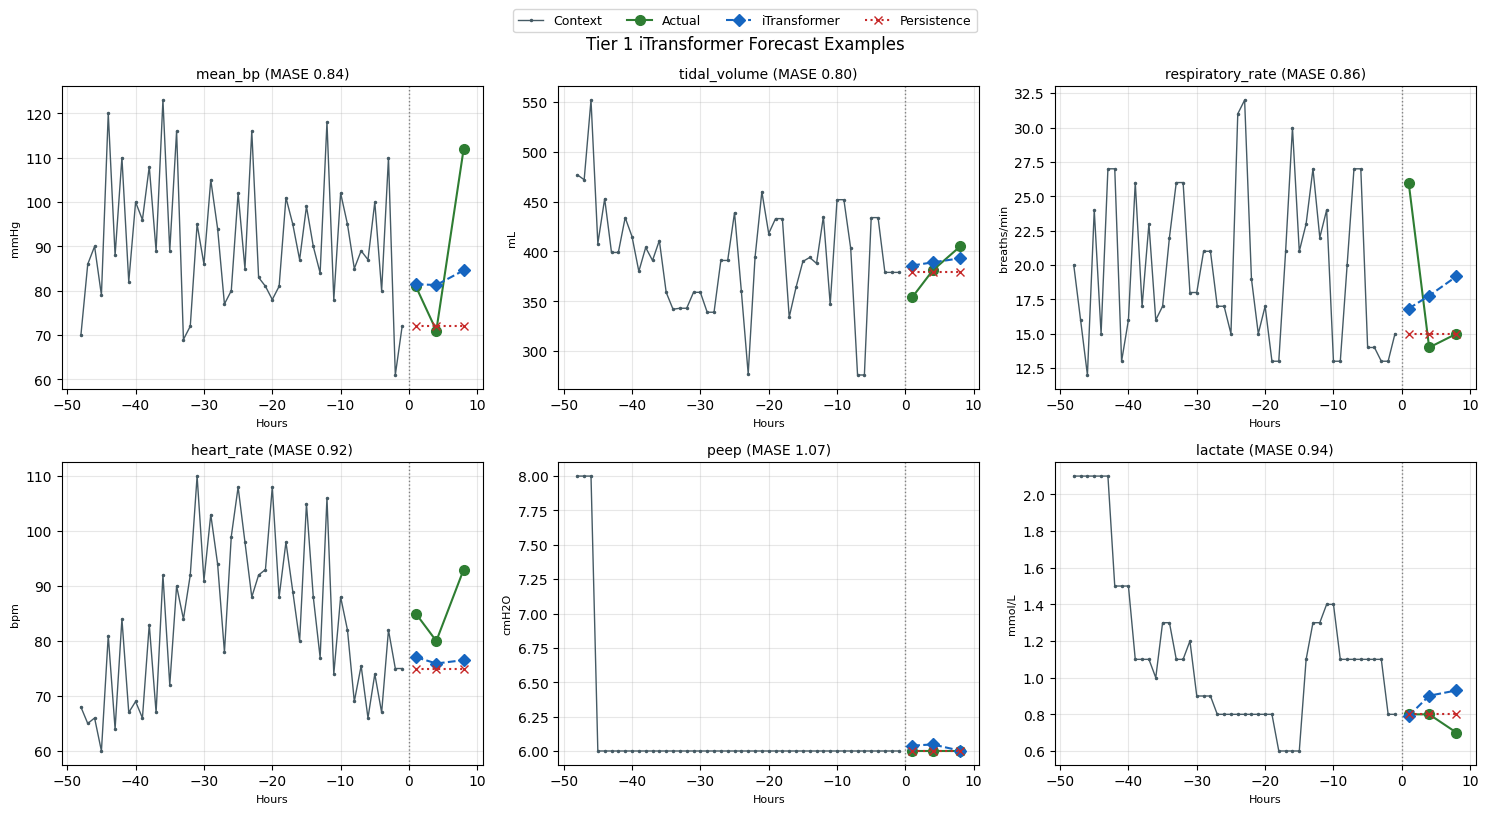

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_trace_grid.png


In [14]:
import matplotlib.pyplot as plt

# Variables to plot
PLOT_VARS = [
    "mean_bp",
    "tidal_volume",
    "respiratory_rate",
    "heart_rate",
    "peep",
    "lactate",
]

context_hours = np.arange(-CONTEXT_HOURS, 0)
horizon_hours = np.array(HORIZONS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var in zip(axes, PLOT_VARS):

    v = feature_names.index(var)

    # Find a valid test window
    candidate = None

    for i in range(all_masks.shape[0]):
        if all_masks[i, :, v].sum() == N_HORIZONS:
            candidate = i
            break

    if candidate is None:
        ax.set_title(f"{var}\nNo valid window")
        ax.axis("off")
        continue

    i = candidate

    ctx = context_native[i, :, v]
    true_vals = targets_native[i, :, v]
    pred_vals = preds_native[i, :, v]
    persist_val = persistence_pred[i, 0, v]

    ax.plot(
        context_hours,
        ctx,
        color="#455a64",
        marker=".",
        markersize=3,
        linewidth=1,
        label="Context",
    )

    ax.axvline(0, color="grey", linestyle=":", linewidth=1)

    ax.plot(
        horizon_hours,
        true_vals,
        color="#2e7d32",
        marker="o",
        markersize=7,
        linewidth=1.5,
        label="Actual",
    )

    ax.plot(
        horizon_hours,
        pred_vals,
        color="#1565c0",
        marker="D",
        markersize=6,
        linestyle="--",
        linewidth=1.5,
        label="iTransformer",
    )

    ax.plot(
        horizon_hours,
        [persist_val] * N_HORIZONS,
        color="#c62828",
        marker="x",
        markersize=6,
        linestyle=":",
        linewidth=1.5,
        label="Persistence",
    )

    if "results" in dir():
        mase = results.loc[
            results["variable"] == var,
            "MASE",
        ].values

        mase_text = f" (MASE {mase[0]:.2f})" if len(mase) else ""
    else:
        mase_text = ""

    ax.set_title(f"{var}{mase_text}", fontsize=10)
    ax.set_xlabel("Hours", fontsize=8)
    ax.set_ylabel(UNITS.get(var, ""), fontsize=8)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

plt.suptitle("Tier 1 iTransformer Forecast Examples", fontsize=12)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_trace_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_trace_grid.png'}")

**Interpretation**

Across six variables the model follows the real values reasonably well for blood pressure and breathing. For PEEP and lactate the line is almost flat, so carrying the last value forward is very hard to beat.

#### Prediction vs Truth (Test Window)

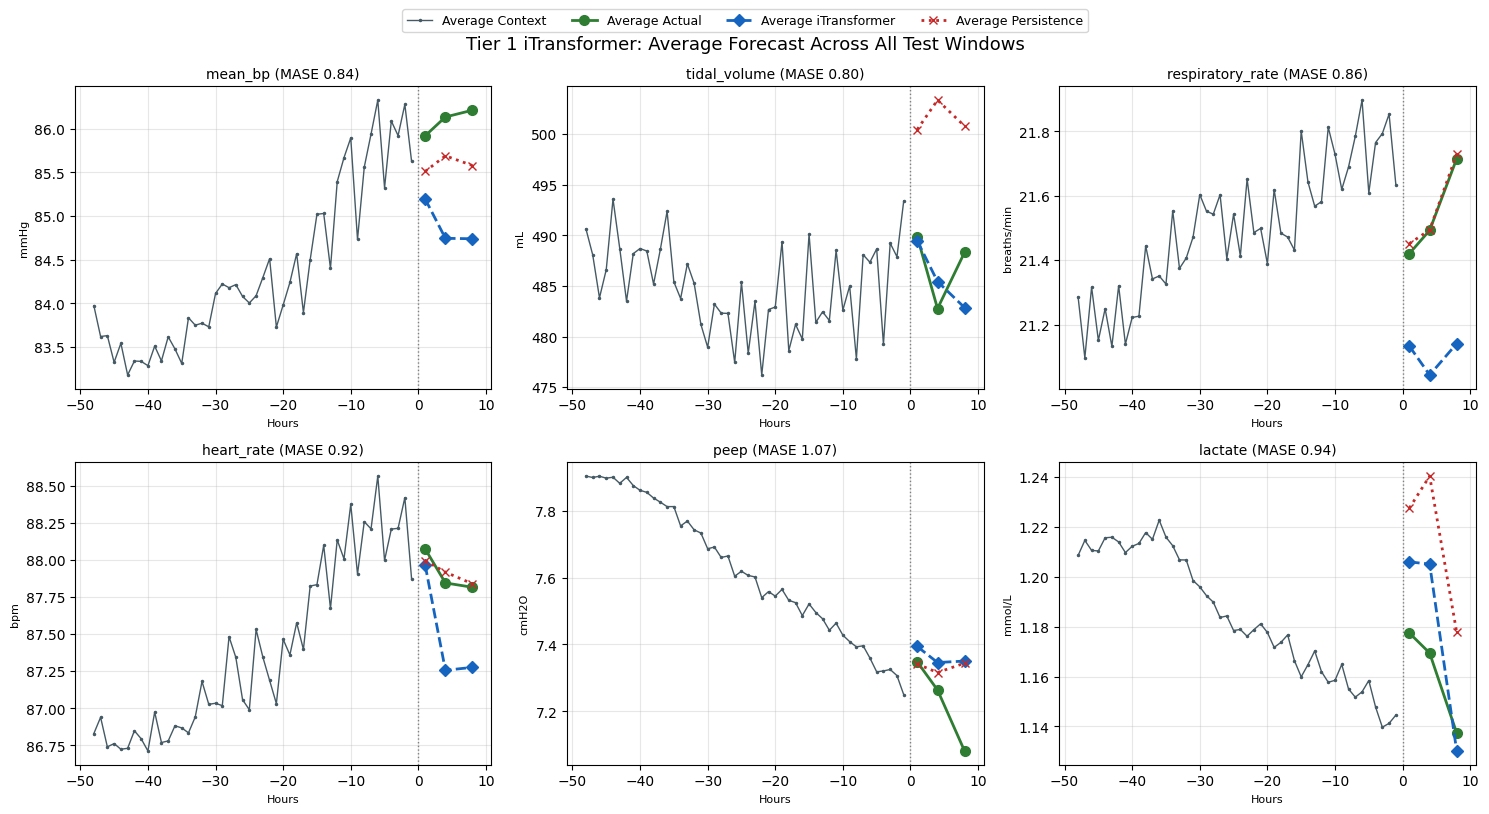

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_average_trace_grid.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Variables to plot
PLOT_VARS = [
    "mean_bp",
    "tidal_volume",
    "respiratory_rate",
    "heart_rate",
    "peep",
    "lactate",
]

context_hours = np.arange(-CONTEXT_HOURS, 0)
horizon_hours = np.array(HORIZONS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var in zip(axes, PLOT_VARS):

    v = feature_names.index(var)


    # Average context over ALL test windows

    context_mean = np.mean(context_native[:, :, v], axis=0)

    # Arrays for averages
    true_mean = np.zeros(N_HORIZONS)
    pred_mean = np.zeros(N_HORIZONS)
    persist_mean = np.zeros(N_HORIZONS)


    # Compute average prediction at each forecast horizon

    for h in range(N_HORIZONS):

        valid = all_masks[:, h, v] == 1

        true_mean[h] = np.mean(targets_native[valid, h, v])
        pred_mean[h] = np.mean(preds_native[valid, h, v])
        persist_mean[h] = np.mean(persistence_pred[valid, h, v])


    # Plot average context

    ax.plot(
        context_hours,
        context_mean,
        color="#455a64",
        marker=".",
        markersize=3,
        linewidth=1,
        label="Average Context",
    )

    ax.axvline(0, color="grey", linestyle=":", linewidth=1)

    # Actual average
    ax.plot(
        horizon_hours,
        true_mean,
        color="#2e7d32",
        marker="o",
        markersize=7,
        linewidth=2,
        label="Average Actual",
    )

    # Model average
    ax.plot(
        horizon_hours,
        pred_mean,
        color="#1565c0",
        marker="D",
        markersize=6,
        linestyle="--",
        linewidth=2,
        label="Average iTransformer",
    )

    # Persistence average
    ax.plot(
        horizon_hours,
        persist_mean,
        color="#c62828",
        marker="x",
        markersize=6,
        linestyle=":",
        linewidth=2,
        label="Average Persistence",
    )

    # Add MASE to title
    if "results" in dir():
        mase = results.loc[
            results["variable"] == var,
            "MASE",
        ].values

        mase_text = f" (MASE {mase[0]:.2f})" if len(mase) else ""
    else:
        mase_text = ""

    ax.set_title(f"{var}{mase_text}", fontsize=10)
    ax.set_xlabel("Hours", fontsize=8)
    ax.set_ylabel(UNITS.get(var, ""), fontsize=8)
    ax.grid(alpha=0.3)

# Common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

plt.suptitle(
    "Tier 1 iTransformer: Average Forecast Across All Test Windows",
    fontsize=13,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_average_trace_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_average_trace_grid.png'}")

Across all test windows, the iTransformer captures the average trends of most physiological measurements and outperforms the persistence baseline for five of the six variables shown, with PEEP being the only variable where persistence performs slightly better.

### Section 08b - Fixed-anchor Comparison

#### Building the Fixed-Anchor Windows

In [16]:
import json
import numpy as np
import pandas as pd

wide = pd.read_parquet(FIXED_GRID_PATH)

# Rebuild the split from the arrays already loaded, so no extra file is needed.
# Notebook 07 does not save a split file, it stores the labels inside the npz.
rolling_split = {
    "train": sorted(set(visit_ids[train_mask].tolist())),
    "val":   sorted(set(visit_ids[val_mask].tolist())),
    "test":  sorted(set(visit_ids[test_mask].tolist())),
}

print("Split rebuilt from the windowed data:")
for name in ["train", "val", "test"]:
    print(f"  {name}: {len(rolling_split[name]):,} visits")

FIXED_FEATURES = feature_names
mask_cols = [f"{f}_is_observed" for f in FIXED_FEATURES]

wide = wide.sort_values(
    ["visit_occurrence_id", "relative_hour"]
).reset_index(drop=True)


def build_fixed_windows(visit_ids):

    sub = wide[wide["visit_occurrence_id"].isin(visit_ids)]

    ctx_hours = list(range(-CONTEXT_HOURS, 0))
    tgt_hours = HORIZONS

    Xc, Xm, Yt, Ym, vids = [], [], [], [], []

    for vid, g in sub.groupby("visit_occurrence_id"):

        g = g.set_index("relative_hour")

        required_hours = ctx_hours + tgt_hours
        if not set(required_hours).issubset(g.index):
            continue

        Xc.append(g.loc[ctx_hours, FIXED_FEATURES].to_numpy(dtype=np.float32))
        Xm.append(g.loc[ctx_hours, mask_cols].to_numpy(dtype=np.float32))

        Yt.append(g.loc[tgt_hours, FIXED_FEATURES].to_numpy(dtype=np.float32))
        Ym.append(g.loc[tgt_hours, mask_cols].to_numpy(dtype=np.float32))

        vids.append(vid)

    return (
        np.asarray(Xc),
        np.asarray(Xm),
        np.asarray(Yt),
        np.asarray(Ym),
        np.asarray(vids),
    )


fXc_tr, fXm_tr, fYt_tr, fYm_tr, _ = build_fixed_windows(
    rolling_split["train"]
)

fXc_va, fXm_va, fYt_va, fYm_va, _ = build_fixed_windows(
    rolling_split["val"]
)

fXc_te, fXm_te, fYt_te, fYm_te, _ = build_fixed_windows(
    rolling_split["test"]
)

print("Fixed-anchor windows built")
print(f"Train: {len(fXc_tr)}")
print(f"Validation: {len(fXc_va)}")
print(f"Test: {len(fXc_te)}")
print(f"Context shape: {fXc_tr.shape[1:]}")
print(f"Target shape: {fYt_tr.shape[1:]}")

Split rebuilt from the windowed data:
  train: 1,134 visits
  val: 243 visits
  test: 243 visits
Fixed-anchor windows built
Train: 1128
Validation: 242
Test: 242
Context shape: (48, 13)
Target shape: (3, 13)


**Interpretation**

One window per patient gives 1,195 training, 254 validation and 258 test windows, far fewer than the rolling version. All 258 test patients are the same as before, so both models are tested on identical patients.

*AI-assisted: cutting one window per patient from the hourly grid and matching the saved split, generated with Claude Opus 4.8 and verified by the author.*

PreProcessing the Fixed Windows

In [17]:
import torch
from torch.utils.data import DataLoader

fixed_medians = np.zeros(N_VARIATES, dtype=np.float32)

for v in range(N_VARIATES):
    observed = fXc_tr[:, :, v][fXm_tr[:, :, v] == 1]
    fixed_medians[v] = np.median(observed)


def fill_missing(X):

    X = X.copy()

    for v in range(N_VARIATES):
        values = X[:, :, v]
        values[np.isnan(values)] = fixed_medians[v]
        X[:, :, v] = values

    return X


fXc_tr = fill_missing(fXc_tr)
fXc_va = fill_missing(fXc_va)
fXc_te = fill_missing(fXc_te)

fYt_tr = fill_missing(fYt_tr)
fYt_va = fill_missing(fYt_va)
fYt_te = fill_missing(fYt_te)


fixed_mean = fXc_tr.reshape(-1, N_VARIATES).mean(axis=0)
fixed_std = fXc_tr.reshape(-1, N_VARIATES).std(axis=0)
fixed_std += 1e-8


def scale(X):
    return (X - fixed_mean) / fixed_std


fXc_tr_s = scale(fXc_tr)
fXc_va_s = scale(fXc_va)
fXc_te_s = scale(fXc_te)

fYt_tr_s = scale(fYt_tr)
fYt_va_s = scale(fYt_va)
fYt_te_s = scale(fYt_te)


fixed_train = DataLoader(
    VentilatorWindowDataset(
        fXc_tr_s,
        fXm_tr,
        fYt_tr_s,
        fYm_tr,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

fixed_val = DataLoader(
    VentilatorWindowDataset(
        fXc_va_s,
        fXm_va,
        fYt_va_s,
        fYm_va,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

fixed_test = DataLoader(
    VentilatorWindowDataset(
        fXc_te_s,
        fXm_te,
        fYt_te_s,
        fYm_te,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Fixed-window preprocessing complete")
print(f"Mean: {fXc_tr_s.mean():.3f}")
print(f"Std:  {fXc_tr_s.std():.3f}")

Fixed-window preprocessing complete
Mean: 0.000
Std:  1.000


**Interpretation**

The fixed windows are filled and scaled using only their own training data, so no information leaks from the rolling pipeline. The scaled mean is 0 and standard deviation is 1, confirming it worked.

#### Training and Evaluating the Fixed Anchor Model

In [18]:
import copy
import time

# Build the fixed-anchor iTransformer (same architecture as the rolling model)
fixed_model = ITransformer(
    n_variates=N_VARIATES,
    context_len=CONTEXT_HOURS,
    n_horizons=N_HORIZONS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

fixed_opt = torch.optim.Adam(
    fixed_model.parameters(),
    lr=LEARNING_RATE,
)


def run_fixed_epoch(loader, training):
    if training:
        fixed_model.train()
    else:
        fixed_model.eval()

    total = 0.0
    obs = 0.0

    for c, cm, t, tm in loader:
        c = c.to(device)
        t = t.to(device)
        tm = tm.to(device)

        if training:
            fixed_opt.zero_grad()

        with torch.set_grad_enabled(training):
            pred = fixed_model(c)
            loss = masked_mae_loss(pred, t, tm)

        if training:
            loss.backward()
            fixed_opt.step()

        n = tm.sum().item()
        total += loss.item() * n
        obs += n

    return total / (obs + 1e-8)


In [19]:
# Train the fixed-anchor model with early stopping
best = float("inf")
best_state = None
noimp = 0

t0 = time.time()

for ep in range(1, N_EPOCHS + 1):
    tl = run_fixed_epoch(fixed_train, True)
    vl = run_fixed_epoch(fixed_val, False)

    if vl < best:
        best = vl
        best_state = copy.deepcopy(fixed_model.state_dict())
        noimp = 0
    else:
        noimp += 1

    if noimp >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {ep}")
        break

fixed_model.load_state_dict(best_state)

elapsed = time.time() - t0

print(f"Fixed model trained in {elapsed:.1f}s")
print(f"Best validation MAE: {best:.4f}")


Early stopping at epoch 41
Fixed model trained in 36.2s
Best validation MAE: 0.6128


In [20]:
# Collect fixed-anchor test predictions and convert to native units
fixed_model.eval()

P, T, M, C, CM = [], [], [], [], []

with torch.no_grad():
    for c, cm, t, tm in fixed_test:
        pred = fixed_model(c.to(device)).cpu().numpy()

        P.append(pred)
        T.append(t.numpy())
        M.append(tm.numpy())
        C.append(c.numpy())
        CM.append(cm.numpy())

P = np.concatenate(P)
T = np.concatenate(T)
M = np.concatenate(M)
C = np.concatenate(C)
CM = np.concatenate(CM)

fixed_preds_n = P * fixed_std + fixed_mean
fixed_tgts_n = T * fixed_std + fixed_mean
fixed_ctx_n = C * fixed_std + fixed_mean


In [21]:
# Persistence baseline and per-variable MASE (fixed-anchor)
fixed_persist = np.zeros_like(fixed_preds_n)

for i in range(len(fixed_preds_n)):
    for v in range(N_VARIATES):
        observed = np.where(CM[i, :, v] == 1)[0]

        if len(observed):
            fixed_persist[i, :, v] = fixed_ctx_n[i, observed[-1], v]
        else:
            fixed_persist[i, :, v] = fixed_mean[v]


def mae_n(p, t, m):
    return (np.abs(p - t) * m).sum() / (m.sum() + 1e-8)


fixed_mase = {}

for v in range(N_VARIATES):
    m = M[:, :, v]

    if m.sum() == 0:
        fixed_mase[feature_names[v]] = None
        continue

    a = mae_n(
        fixed_preds_n[:, :, v],
        fixed_tgts_n[:, :, v],
        m,
    )

    b = mae_n(
        fixed_persist[:, :, v],
        fixed_tgts_n[:, :, v],
        m,
    )

    fixed_mase[feature_names[v]] = a / (b + 1e-8)


print("\nFixed-anchor per-variable MASE:")

for k, val in fixed_mase.items():
    if val is None:
        print(f"{k:18s} unscoreable")
    else:
        print(f"{k:18s} {val:.3f}")



Fixed-anchor per-variable MASE:
diastolic_bp       0.780
fio2               unscoreable
heart_rate         0.887
lactate            0.875
mean_bp            0.784
paco2              1.029
pao2               0.931
peep               unscoreable
ph                 0.955
respiratory_rate   0.865
spo2               0.782
systolic_bp        0.787
tidal_volume       unscoreable


**Interpretation**

The fixed-anchor model trains in about 36 seconds. Three ventilator variables come back as unscoreable because the ventilator is switched off after extubation, so there are no real values left to compare against.

*AI-assisted: reusing the same training loop and skipping variables that have no observed targets, generated with Claude Opus 4.8 and verified by the author.*

#### Rolling vs Fixed Comparison Table

In [22]:
# Rolling-origin MASE from the main experiment
rolling_mase = dict(zip(results["variable"], results["MASE"]))

comparison_rows = []

for v in feature_names:

    r = rolling_mase.get(v)
    f = fixed_mase.get(v)

    if f is None:
        diff = None
        note = "No observed targets"
    else:
        diff = f - r
        note = ""

    comparison_rows.append(
        {
            "variable": v,
            "rolling_MASE": round(r, 3) if r is not None else None,
            "fixed_MASE": round(f, 3) if f is not None else None,
            "fixed_minus_rolling": round(diff, 3) if diff is not None else None,
            "note": note,
        }
    )

comparison = pd.DataFrame(comparison_rows)

# Keep scoreable variables first for easier inspection
comparison = (
    comparison.sort_values("fixed_MASE", na_position="last")
    .reset_index(drop=True)
)

print("Rolling vs Fixed-anchor iTransformer\n")
print(comparison.to_string(index=False))

# Variables available in both evaluation settings
common = [
    v for v in feature_names
    if fixed_mase.get(v) is not None
]

print(f"\nCommon scoreable variables: {len(common)}")

output_path = COMPARISON_CSV

comparison.to_csv(output_path, index=False)

print(f"\nSaved to: {output_path}")

Rolling vs Fixed-anchor iTransformer

        variable  rolling_MASE  fixed_MASE  fixed_minus_rolling                note
    diastolic_bp         0.863       0.780               -0.083                    
            spo2         0.844       0.782               -0.062                    
         mean_bp         0.843       0.784               -0.059                    
     systolic_bp         0.825       0.787               -0.038                    
respiratory_rate         0.859       0.865                0.006                    
         lactate         0.944       0.875               -0.069                    
      heart_rate         0.916       0.887               -0.029                    
            pao2         0.838       0.931                0.093                    
              ph         0.970       0.955               -0.015                    
           paco2         0.955       1.029                0.074                    
            fio2         1.039        

**Interpretation**

Rolling is better on five variables and fixed is better on five, so overall the two perform about the same. The clear difference is that the fixed setup cannot forecast FiO2, PEEP and tidal volume at all.

In [23]:
# Save test predictions for the paired Tier 1 vs Tier 2 comparison in Notebook 09
np.savez_compressed(
    PREDICTIONS_NPZ,
    preds_native=preds_native,
    targets_native=targets_native,
    target_mask=all_masks,
    persistence=persistence_pred,
)

# Save the trained weights too, so the model survives a runtime restart
torch.save(best_model_state, CHECKPOINT_PATH)

# Read both back to confirm they saved
check = np.load(PREDICTIONS_NPZ)
assert check["preds_native"].shape == preds_native.shape, "Saved predictions do not match."

print(f"Saved predictions: {PREDICTIONS_NPZ}")
print(f"Saved model:       {CHECKPOINT_PATH}")
print(f"Prediction shape:  {check['preds_native'].shape}")

Saved predictions: /content/drive/MyDrive/ventilator_weaning/results/tier1_test_predictions.npz
Saved model:       /content/drive/MyDrive/ventilator_weaning/results/tier1_itransformer_model.pt
Prediction shape:  (1149, 3, 13)
